# Exercício 8.2 — Visualização de Embeddings com t-SNE

Exercício do *Mini-Lab: Embeddings e Vetores com BERT* (seção 8.2).

**Objetivo:** explorar a projeção 2D dos embeddings (SBERT) e verificar se textos do mesmo tema formam agrupamentos (clusters) no mapa.

## Contexto

- Embeddings têm alta dimensão (384, 768...). Para "ver" padrões, projetamos para 2D.
- **t-SNE** tenta manter **vizinhanças locais**: pontos próximos em alta dimensão tendem a ficar próximos em 2D.
- É ótimo para enxergar clusters; **não preserva distâncias globais** e pode variar entre execuções.
- Parâmetro importante: `perplexity` (ex.: 10, 15, 20) — controla a granularidade dos agrupamentos.

Este notebook é autocontido e usa o mesmo dataset do mini‑lab. Execute as células em ordem.

## 1) Imports

In [25]:
import numpy as np
import pandas as pd

from sklearn.manifold import TSNE

import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

## 2) Dataset (mesmo do mini‑lab)

In [26]:
texts = [
    'O Kubernetes organiza aplicações em contêineres usando pods e namespaces.',
    'BERT é um modelo de linguagem baseado em Transformers com atenção bidirecional.',
    'TF-IDF representa textos como vetores esparsos de termos com pesos.', 
    'O Keycloak é uma solução de identidade para autenticação e single sign-on (SSO).',
    'Uma rede neural pode aprender representações úteis para classificação de texto.',
    'Esteatose hepática é o acúmulo de gordura no fígado e pode ser associada a obesidade.',
    'Exercícios físicos regulares ajudam a melhorar a saúde cardiovascular.',
    'Uma dieta balanceada inclui proteínas, carboidratos, fibras e gorduras saudáveis.',
    'Em Paris, o metrô e o RER conectam pontos turísticos e regiões metropolitanas.',
    'Em Budapeste, os banhos termais são uma atração tradicional muito conhecida.',
    'A culinária francesa inclui pratos como confit de pato e magret de pato.',
    'O t-SNE projeta dados de alta dimensão para 2D preservando vizinhanças locais.',
    'Embeddings transformam texto em vetores densos que capturam semântica.', 
    'Similaridade cosseno mede o alinhamento entre dois vetores.',
    'O SharePoint Online permite criar sites, listas e páginas para intranet corporativa.',
    'Power Automate automatiza fluxos de trabalho integrando serviços do Microsoft 365.',
    'Uma VPN cria um túnel criptografado para acessar recursos internos remotamente.',
    'RAG combina recuperação de documentos com geração de texto por LLMs.',
    'O MinIO é um storage compatível com S3 para objetos.',
    'Milvus é um banco de dados vetorial para busca por similaridade.',
    'O GitHub Actions executa pipelines de CI/CD para build e deploy.',
    'A normalização L2 ajusta vetores para terem norma 1.', 
    'O produto escalar soma multiplicações elemento a elemento entre dois vetores.',
    'Uma eSIM permite usar planos móveis sem um chip físico tradicional.',
    'Um fone com cancelamento de ruído reduz sons externos usando processamento de sinal.',
    'Um condomínio possui área privativa e área de uso comum em sua composição.',
    'O risco de duplicação de eventos pode ser evitado guardando IDs em uma planilha.',
    'O termo underfitting indica um modelo simples demais para capturar padrões.',
    'A técnica de mean pooling tira a média dos embeddings dos tokens de uma frase.',
    'O token [CLS] pode ser usado como representação agregada em modelos BERT.',
    'O Docker empacota aplicações em imagens para rodar em qualquer ambiente.',
    'O PostgreSQL é um banco de dados relacional com suporte a transações ACID.',
    'O Grafana monitora métricas de sistemas e exibe painéis em tempo real.',
    'Uma API REST expõe recursos por meio de endpoints HTTP.',
    'O Terraform provisiona infraestrutura como código em provedores de nuvem.',
    'O Elasticsearch indexa documentos e permite buscas rápidas por texto completo.',
    'O modelo BERTimbau é um BERT treinado especificamente para o português.',
    'O vetor denso de uma frase pode ser comparado com similaridade cosseno.',
    'Um paciente hipertenso deve reduzir o consumo de sal e praticar exercícios.',
    'A diabetes tipo 2 está relacionada à resistência à insulina e à obesidade.',
    'O sushi é um prato japonês feito de arroz temperado e peixe cru.',
    'Em Roma, o Coliseu e o Vaticano são as principais atrações turísticas.',
    'Um fone Bluetooth emparelha com dispositivos sem a necessidade de cabos.',
    'Um data center precisa de refrigeração e energia elétrica redundante.',
    'O Ngrok expõe servidores locais para a internet pública temporariamente.',
    'O PyTorch é um framework de deep learning com autograd automático.',
    'A matriz de confusão resume acertos e erros de um classificador.',
    'A regularização L1 e L2 ajuda a evitar overfitting em modelos.',
    'Um site institucional deve ser responsivo para telas de celular.',
    'O SPF e o DMARC protegem domínios contra falsificação de e-mails.',
]

df = pd.DataFrame({'id': range(len(texts)), 'text': texts})
df

,id,text
0,0,O Kubernetes organiza aplicações em contêinere...
1,1,BERT é um modelo de linguagem baseado em Trans...
2,2,TF-IDF representa textos como vetores esparsos...
3,3,O Keycloak é uma solução de identidade para au...
4,4,Uma rede neural pode aprender representações ú...
5,5,Esteatose hepática é o acúmulo de gordura no f...
6,6,Exercícios físicos regulares ajudam a melhorar...
7,7,"Uma dieta balanceada inclui proteínas, carboid..."
8,8,"Em Paris, o metrô e o RER conectam pontos turí..."
9,9,"Em Budapeste, os banhos termais são uma atraçã..."


## 3) Embeddings com SBERT

In [27]:
import torch
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cpu'

In [28]:
sbert_model_name = 'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2'
sbert = SentenceTransformer(sbert_model_name, device=device)

X_sbert = sbert.encode(texts, convert_to_numpy=True, normalize_embeddings=True)
X_sbert.shape

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 7129.58it/s]


(50, 384)

## 4) Visualização base (perplexity = 10)

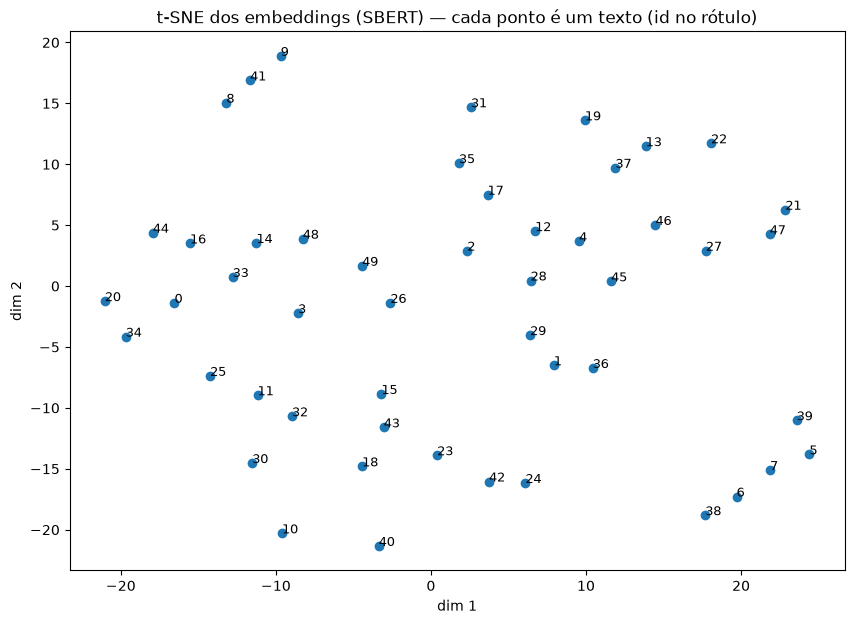

In [29]:
tsne = TSNE(n_components=2, perplexity=10, random_state=42, init='pca', learning_rate='auto')
Z = tsne.fit_transform(X_sbert)

plt.figure(figsize=(10, 7))
plt.scatter(Z[:, 0], Z[:, 1])

for i, _ in enumerate(texts):
    plt.text(Z[i, 0], Z[i, 1], str(i), fontsize=9)

plt.title('t-SNE dos embeddings (SBERT) — cada ponto é um texto (id no rótulo)')
plt.xlabel('dim 1')
plt.ylabel('dim 2')
plt.show()

## 5) O exercício (8.2)

1) Escolha **3–5 textos** que você acha que são do **mesmo tema** (ex.: "infra de TI", "saúde", "viagens", "culinária").
2) Veja se os **IDs** desses textos aparecem **próximos no mapa**.
3) Se não aparecerem, tente:
   - aumentar `perplexity` para **15** ou **20**;
   - ou usar **mais textos** do mesmo tema.

Dica: use a tabela abaixo para conferir qual texto corresponde a cada ID.

In [30]:
df[['id', 'text']]

,id,text
0,0,O Kubernetes organiza aplicações em contêinere...
1,1,BERT é um modelo de linguagem baseado em Trans...
2,2,TF-IDF representa textos como vetores esparsos...
3,3,O Keycloak é uma solução de identidade para au...
4,4,Uma rede neural pode aprender representações ú...
5,5,Esteatose hepática é o acúmulo de gordura no f...
6,6,Exercícios físicos regulares ajudam a melhorar...
7,7,"Uma dieta balanceada inclui proteínas, carboid..."
8,8,"Em Paris, o metrô e o RER conectam pontos turí..."
9,9,"Em Budapeste, os banhos termais são uma atraçã..."


### 5.1 Ferramenta de comparação

Função que plota o t-SNE com uma `perplexity` qualquer. Rode para 15 e 20 e compare.

In [31]:
def plot_tsne(perplexity: int = 10, highlight_ids: list[int] | None = None, groups: dict | None = None):
    # groups: {nome_do_grupo: ([ids], cor)}
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='pca', learning_rate='auto')
    Z = tsne.fit_transform(X_sbert)

    plt.figure(figsize=(10, 7))
    plt.scatter(Z[:, 0], Z[:, 1], alpha=0.4, color='lightgray')

    for i, _ in enumerate(texts):
        plt.text(Z[i, 0], Z[i, 1], str(i), fontsize=9)

    if groups:
        for label, (ids, color) in groups.items():
            h = list(ids)
            plt.scatter(Z[h, 0], Z[h, 1], color=color, edgecolors='black', s=120, label=label)
        plt.legend()
    elif highlight_ids:
        h = list(highlight_ids)
        plt.scatter(Z[h, 0], Z[h, 1], color='red', edgecolors='black', s=120, label='meus textos')
        plt.legend()

    plt.title(f't-SNE (SBERT) — perplexity={perplexity}')
    plt.xlabel('dim 1')
    plt.ylabel('dim 2')
    plt.show()


Textos escolhidos por grupo:

1:
  [5] Esteatose hepática é o acúmulo de gordura no fígado e pode ser associada a obesidade.
  [6] Exercícios físicos regulares ajudam a melhorar a saúde cardiovascular.
  [7] Uma dieta balanceada inclui proteínas, carboidratos, fibras e gorduras saudáveis.

2:
  [0] O Kubernetes organiza aplicações em contêineres usando pods e namespaces.
  [16] Uma VPN cria um túnel criptografado para acessar recursos internos remotamente.
  [20] O GitHub Actions executa pipelines de CI/CD para build e deploy.

3:
  [3] O Keycloak é uma solução de identidade para autenticação e single sign-on (SSO).
  [12] Embeddings transformam texto em vetores densos que capturam semântica.
  [21] A normalização L2 ajusta vetores para terem norma 1.


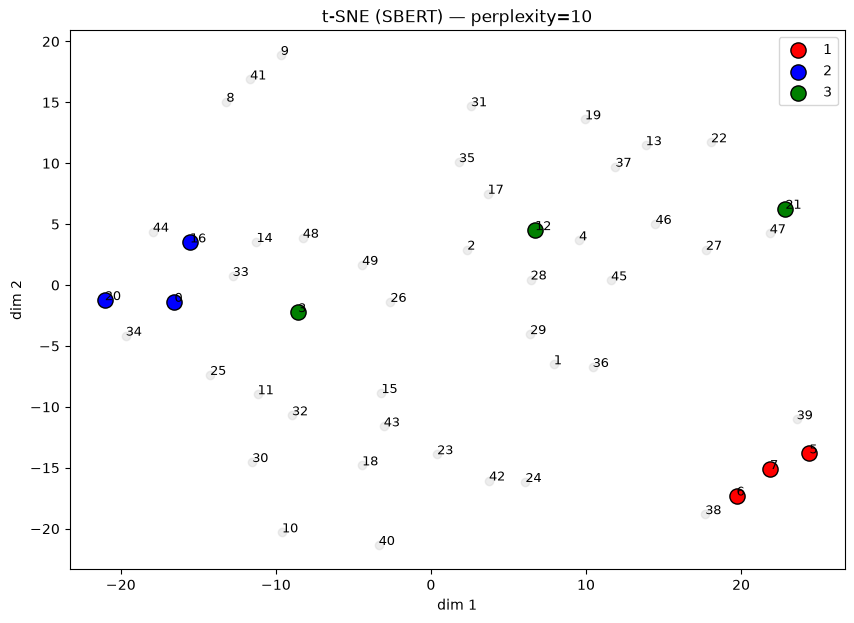

In [32]:
# Três baterias de textos do mesmo tema — cada uma com uma cor
grupos = {
    '1': ([5, 6, 7], 'red'),
    '2': ([0, 16, 20], 'blue'),
    '3': ([3, 12, 21], 'green'),
}

print('Textos escolhidos por grupo:')
for label, (ids, _) in grupos.items():
    print(f'\n{label}:')
    for i in ids:
        print(f'  [{i}] {texts[i]}')

plot_tsne(perplexity=10, groups=grupos)


### 5.2 Compare perplexity

Rode o mesmo conjunto com perplexity **15** e **20** e veja se os agrupamentos mudam.

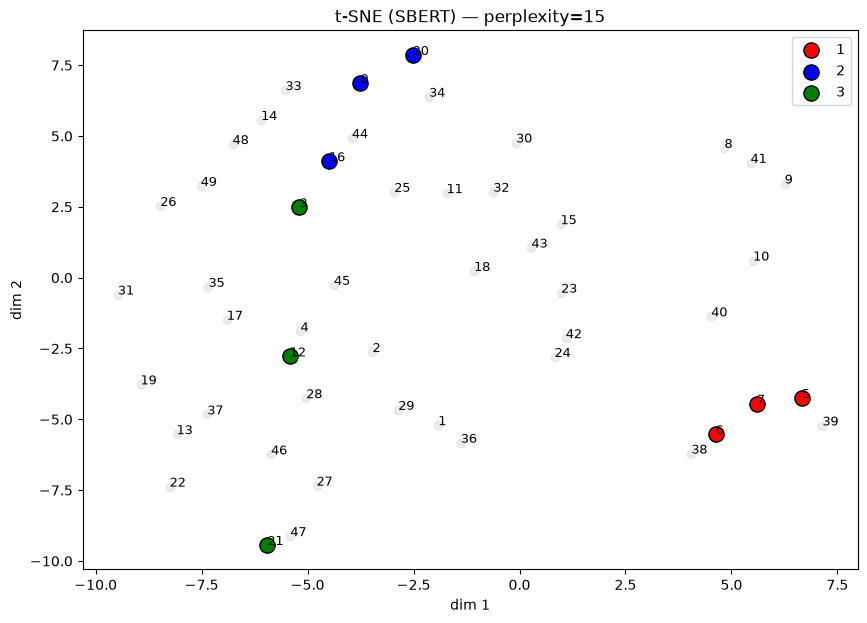

In [33]:
plot_tsne(perplexity=15, groups=grupos)


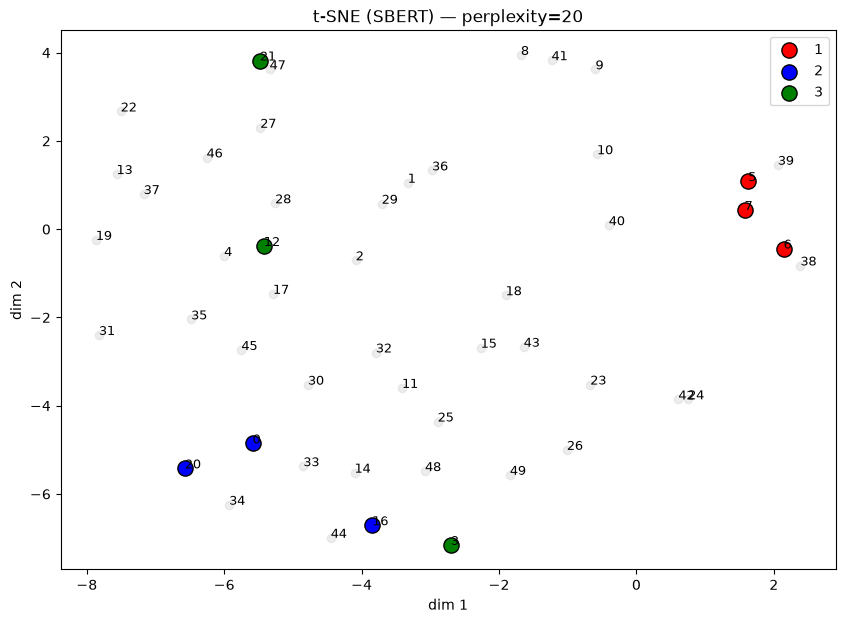

In [34]:
plot_tsne(perplexity=20, groups=grupos)


## 6) Responda

1) Quais **3–5 textos do mesmo tema** você escolheu (IDs)?

R.: 

3 Baterias de textos escolhidas para comparação:

1. 5, 6 e 7.     Saúde    
2. 3, 12 e 21.   Vetores ( CTRL + F e vetores) 
3. 0, 16 e 20.   Infra de TI



2) Eles apareceram **próximos** no mapa com perplexity=10?

R.: 
1. 5, 6 e 7.      IDs próximos no mapa.
2. 3, 12 e 21.    IDs distantes no mapa.
3. 0, 16 e 20.    IDs próximos no mapa.


3) O que **mudou** com perplexity = 15 e 20?

R.: 
1. 5, 6 e 7.      Para P=15, os IDs se aproximaram ainda mais. Para P=20, os IDs se aproximaram ainda mais.
2. 3, 12 e 21.    Para P=15, os IDs se aproximaram sem relação a P=10, mas se mantiveram distantes. Para P=20, os IDs voltaram a se afastar, porém estão mais proximos do que P=10.
3. 0, 16 e 20.    Para P=15, os IDs se afastaram em relação a P = 10, se mantendo relativamente próximos. Para P=20, os IDs se aproximaram, mantendo-se a praticamente a mesma distancia de P = 10.


4) Se não apareceram próximos, o que você tentou? (mais textos do tema? perplexity maior?)

R.: Na bateria 2 ao colocar o perplexity como 15 eles se aproximaram, mas se mantiveram a uma distancia consideravel, perplexity como 20 voltaram a se afastar.

## 7) Extras (opcional)

- Adicione mais textos do mesmo tema no dataset e rode novamente.
- Compare com o mapa do **PCA** (sklearn `PCA(n_components=2)`) e veja a diferença.
- Teste outros valores de `random_state` para ver como o t-SNE varia.

### Textos adicionados para o extra (IDs 30–49)

- **id 30:** O Docker empacota aplicações em imagens para rodar em qualquer ambiente.
- **id 31:** O PostgreSQL é um banco de dados relacional com suporte a transações ACID.
- **id 32:** O Grafana monitora métricas de sistemas e exibe painéis em tempo real.
- **id 33:** Uma API REST expõe recursos por meio de endpoints HTTP.
- **id 34:** O Terraform provisiona infraestrutura como código em provedores de nuvem.
- **id 35:** O Elasticsearch indexa documentos e permite buscas rápidas por texto completo.
- **id 36:** O modelo BERTimbau é um BERT treinado especificamente para o português.
- **id 37:** O vetor denso de uma frase pode ser comparado com similaridade cosseno.
- **id 38:** Um paciente hipertenso deve reduzir o consumo de sal e praticar exercícios.
- **id 39:** A diabetes tipo 2 está relacionada à resistência à insulina e à obesidade.
- **id 40:** O sushi é um prato japonês feito de arroz temperado e peixe cru.
- **id 41:** Em Roma, o Coliseu e o Vaticano são as principais atrações turísticas.
- **id 42:** Um fone Bluetooth emparelha com dispositivos sem a necessidade de cabos.
- **id 43:** Um data center precisa de refrigeração e energia elétrica redundante.
- **id 44:** O Ngrok expõe servidores locais para a internet pública temporariamente.
- **id 45:** O PyTorch é um framework de deep learning com autograd automático.
- **id 46:** A matriz de confusão resume acertos e erros de um classificador.
- **id 47:** A regularização L1 e L2 ajuda a evitar overfitting em modelos.
- **id 48:** Um site institucional deve ser responsivo para telas de celular.
- **id 49:** O SPF e o DMARC protegem domínios contra falsificação de e-mails.
